# Una ola de calor, 32 especies, y el mapa de quién sobrevive

En junio de 2021, el noroeste de Norteamérica registró temperaturas hasta 30 °C por encima de lo normal. ¿Qué les pasó a las especies que viven ahí?

---

**Paper:** Baum et al. (2026) *Widespread ecological responses and cascading effects of the 2021 western North American heatwave*
**Journal:** Nature Ecology & Evolution
**DOI:** [10.1038/s41559-026-02987-6](https://doi.org/10.1038/s41559-026-02987-6)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-17-ola-calor-32-especies/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=Ia61CV8VKvY)

## La ola de calor más extrema de la historia reciente

La ola de calor de 2021 en el oeste de Norteamérica (conocida como *heat dome*) rompió récords de temperatura en Canadá (49,6 °C en Lytton, Columbia Británica) y mató a más de 1.000 personas. Pero ¿qué pasó con el resto de los seres vivos?

Un equipo de más de 60 investigadores recopiló datos de **25 especies** — desde áfidos y mejillones hasta lobos y murciélagos — y midió cómo cambió su abundancia, supervivencia o reproducción durante y después de la ola de calor, comparando con años anteriores. También midieron incendios forestales y caudal de ríos.

Lo que hicieron es un meta-análisis: para cada especie calcularon un **tamaño de efecto** (log response ratio) — básicamente, cuánto cambió respecto al periodo de control.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_NEGATIVO = 0           # Umbral para considerar "impacto negativo" (% cambio)
FUENTE = 'Fuente: Baum et al. (2026), Nature Ecology & Evolution | Datos: GitHub/Zenodo'
COLOR_NEG = '#DC2626'         # Rojo — impacto negativo
COLOR_POS = '#059669'         # Emerald — impacto positivo
COLOR_DATOS = '#2563EB'       # Azul CaM
COLOR_HIST = '#BBBBBB'        # Gris — histórico
COLOR_FIRE = '#D97706'        # Amber — incendios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
es = pd.read_csv('datos/effectsizes.csv')
wf21 = pd.read_csv('datos/wildfire_stats_2021.csv')
wf_hist = pd.read_csv('datos/wildfire_stats_2000_2020.csv')

# Computar % cambio desde log response ratio
es['pct_change'] = (np.exp(es.yi) - 1) * 100
es['se_pct'] = np.sqrt(es.vi) * 100  # Error estándar aproximado en %

# Agregar por especie
sp = es.groupby(['genus_species', 'region', 'movement']).agg(
    mean_pct=('pct_change', 'mean'),
    mean_yi=('yi', 'mean'),
    mean_vi=('vi', 'mean'),
    n=('yi', 'count')
).reset_index().sort_values('mean_pct')
sp['se'] = np.sqrt(sp.mean_vi) * 100

neg = (sp.mean_pct < UMBRAL_NEGATIVO).sum()
total = len(sp)
print(f"Especies: {total}")
print(f"Negativamente impactadas: {neg}/{total} ({neg/total*100:.0f}%)")
print(f"Rango: {sp.mean_pct.min():.0f}% a +{sp.mean_pct.max():.0f}%")
print(f"Mediana: {sp.mean_pct.median():.1f}%")

Especies: 25
Negativamente impactadas: 17/25 (68%)
Rango: -99% a +51%
Mediana: -30.4%


## El mapa de daños

Aquí está.

/tmp/ipykernel_4640/914641518.py:40: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.savefig('figuras/forest_plot_especies.png', dpi=200, bbox_inches='tight')
/tmp/ipykernel_4640/914641518.py:40: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('figuras/forest_plot_especies.png', dpi=200, bbox_inches='tight')


/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


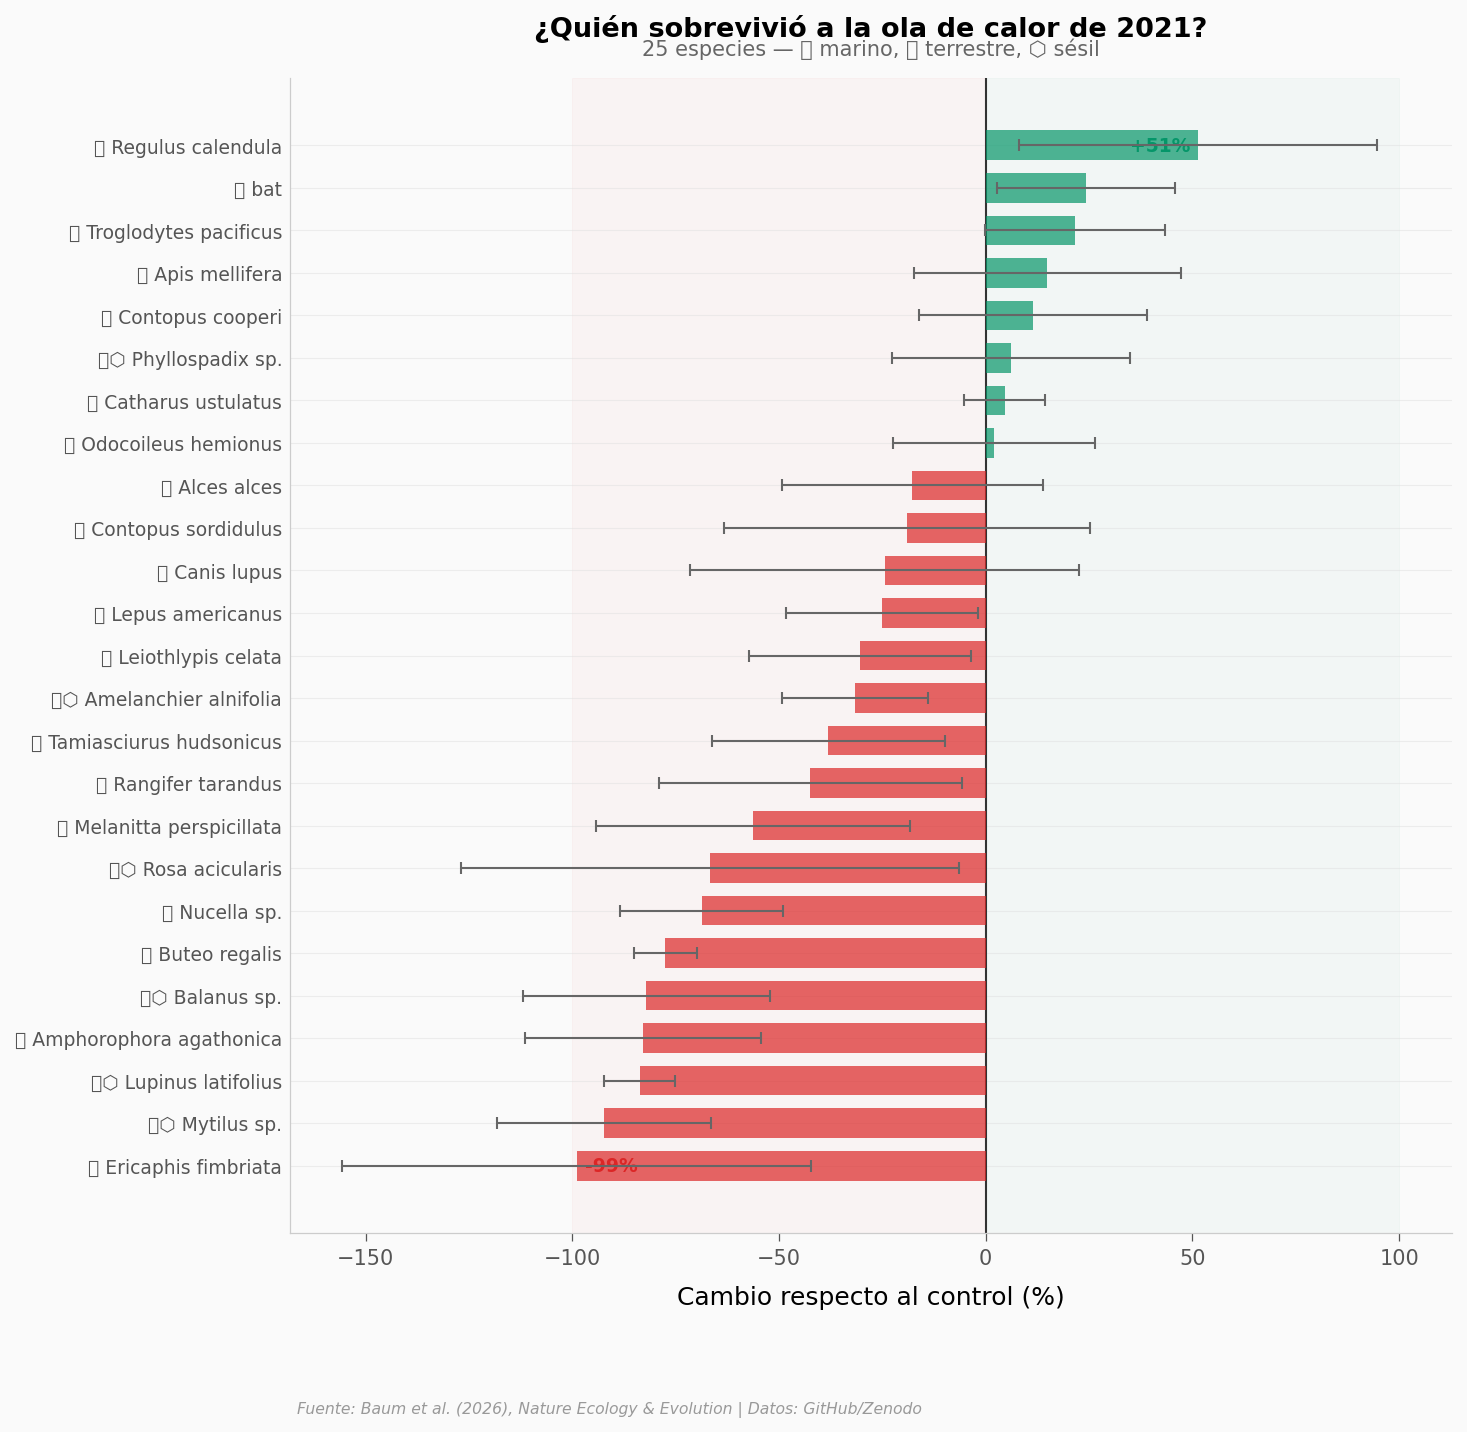

In [2]:
# Forest plot: impacto por especie
fig, ax = plt.subplots(figsize=(10, 10))

y_pos = range(len(sp))
colors = [COLOR_NEG if v < 0 else COLOR_POS for v in sp.mean_pct.values]

ax.barh(list(y_pos), sp.mean_pct.values, color=colors, alpha=0.7, height=0.7, zorder=3)
ax.errorbar(sp.mean_pct.values, list(y_pos), xerr=sp.se.values,
            fmt='none', color='#666666', capsize=3, linewidth=1, zorder=4)

# Species labels
labels = []
for _, row in sp.iterrows():
    name = row.genus_species.replace('sp.', 'sp.')
    icon = '🌊' if row.region == 'marine' else '🌲'
    mob = '⬡' if row.movement == 'sessile' else ''
    labels.append(f'{icon}{mob} {name}')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(x=0, color='#333333', linewidth=1, linestyle='-', zorder=2)

# Reference zone
ax.axvspan(-100, 0, alpha=0.03, color=COLOR_NEG, zorder=1)
ax.axvspan(0, 100, alpha=0.03, color=COLOR_POS, zorder=1)

ax.set_xlabel('Cambio respecto al control (%)', fontsize=12)
ax.set_title('¿Quién sobrevivió a la ola de calor de 2021?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(sp)} especies — 🌊 marino, 🌲 terrestre, ⬡ sésil',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Annotate extremes
ax.text(sp.mean_pct.values[0] + 2, 0, f'{sp.mean_pct.values[0]:.0f}%',
        fontsize=9, color=COLOR_NEG, fontweight='bold', va='center')
ax.text(sp.mean_pct.values[-1] - 2, len(sp)-1, f'+{sp.mean_pct.values[-1]:.0f}%',
        fontsize=9, color=COLOR_POS, fontweight='bold', va='center', ha='right')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/forest_plot_especies.png', dpi=200, bbox_inches='tight')
plt.show()

El patrón que salta a la vista: los organismos sésiles marinos (mejillones, percebes, algas) tendieron a sufrir los peores declives — hasta -99% en el caso de los áfidos de los arándanos. Los mamíferos y aves, con capacidad de moverse a refugios, resistieron mejor. Algunos incluso aumentaron: los murciélagos (+24%), los reyezuelos (*Regulus calendula*, +51%).

La mediana del efecto es -30% — la especie "típica" perdió casi un tercio de su abundancia o reproducción.

## ¿Importa poder moverse?

Si puedes huir a la sombra o migrar a zonas más frescas, la ola de calor te afecta menos. Veamos si los datos lo confirman.

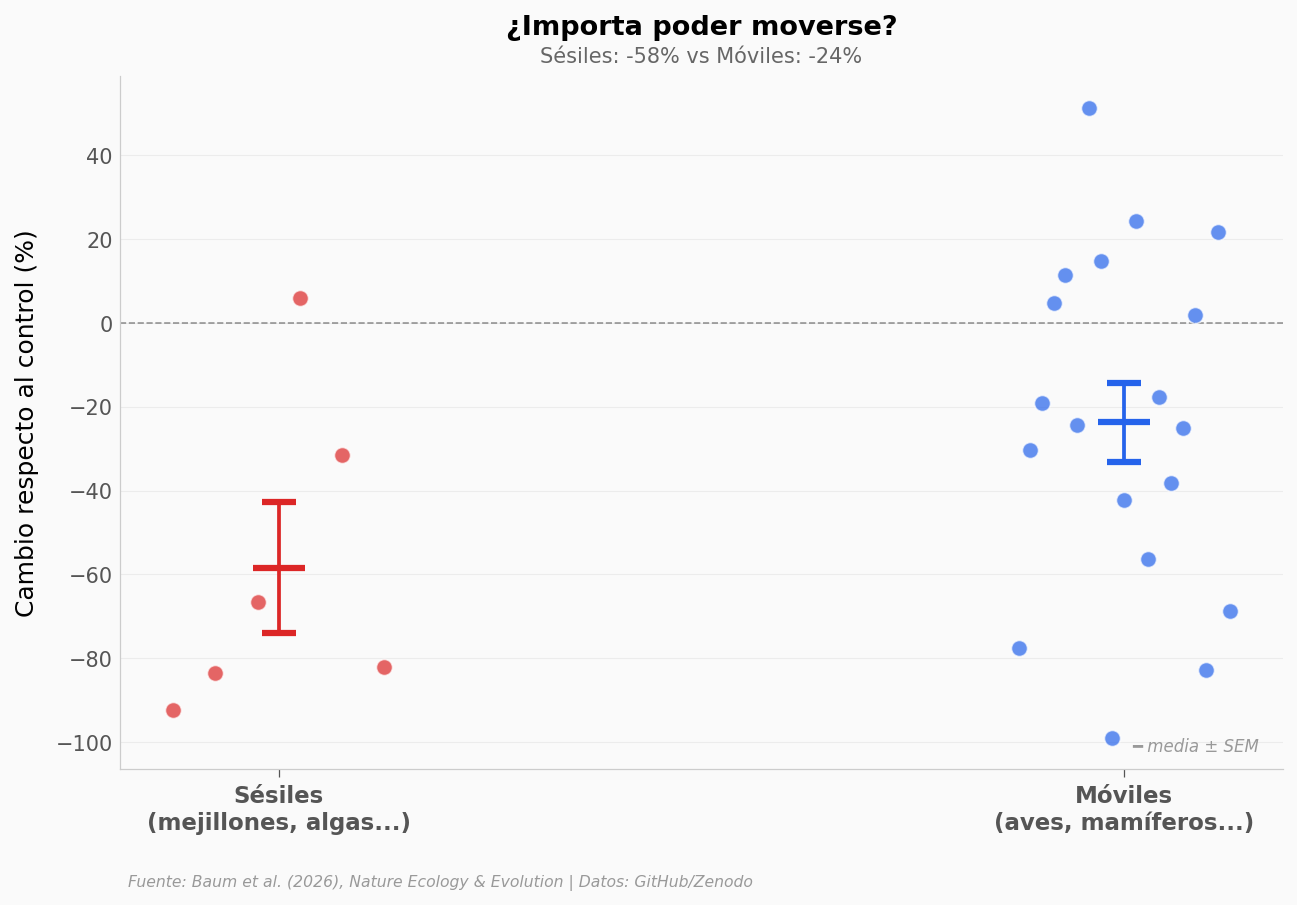

Sésiles: media=-58.4%, n=6
Móviles: media=-23.7%, n=19
Mann-Whitney U (sésiles < móviles): U=29, p=0.0400, Cohen's d=-0.86


In [3]:
# Comparación sésiles vs móviles
fig, ax = plt.subplots(figsize=(10, 6))

np.random.seed(42)
groups = [
    ('Sésiles\n(mejillones, algas...)', sp[sp.movement == 'sessile'].mean_pct.values, COLOR_NEG),
    ('Móviles\n(aves, mamíferos...)', sp[sp.movement == 'motile'].mean_pct.values, COLOR_DATOS),
]

positions = [0, 1.2]
for i, (label, vals, color) in enumerate(groups):
    n = len(vals)
    x_jitter = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
    np.random.shuffle(x_jitter)
    ax.scatter(x_jitter, vals, color=color, s=60, alpha=0.7,
               edgecolors='white', linewidths=0.8, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=25, markeredgewidth=3, capsize=8, capthick=1.5, zorder=6)

ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(positions)
ax.set_xticklabels([g[0] for g in groups], fontsize=11, fontweight='bold')
ax.set_ylabel('Cambio respecto al control (%)', fontsize=12)
ax.set_title('¿Importa poder moverse?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Sésiles: {sp[sp.movement=="sessile"].mean_pct.mean():.0f}% vs Móviles: {sp[sp.movement=="motile"].mean_pct.mean():.0f}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sesiles_vs_moviles.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
sessile = sp[sp.movement == 'sessile'].mean_pct.values
motile = sp[sp.movement == 'motile'].mean_pct.values
from scipy import stats
u_stat, u_p = stats.mannwhitneyu(sessile, motile, alternative='less')
print(f"Sésiles: media={sessile.mean():.1f}%, n={len(sessile)}")
print(f"Móviles: media={motile.mean():.1f}%, n={len(motile)}")
cohens_d = (sessile.mean() - motile.mean()) / np.sqrt(((len(sessile)-1)*sessile.std(ddof=1)**2 + (len(motile)-1)*motile.std(ddof=1)**2) / (len(sessile)+len(motile)-2))
print(f"Mann-Whitney U (sésiles < móviles): U={u_stat:.0f}, p={u_p:.4f}, Cohen's d={cohens_d:.2f}")

Los organismos sésiles sufrieron en promedio un declive de -58%, frente a -24% de los móviles. La diferencia tiene sentido biológico: un mejillón pegado a una roca no puede huir a la sombra; un ciervo sí.

## ¿Y los incendios?

La ola de calor no solo afectó a los seres vivos directamente — también encendió el paisaje.

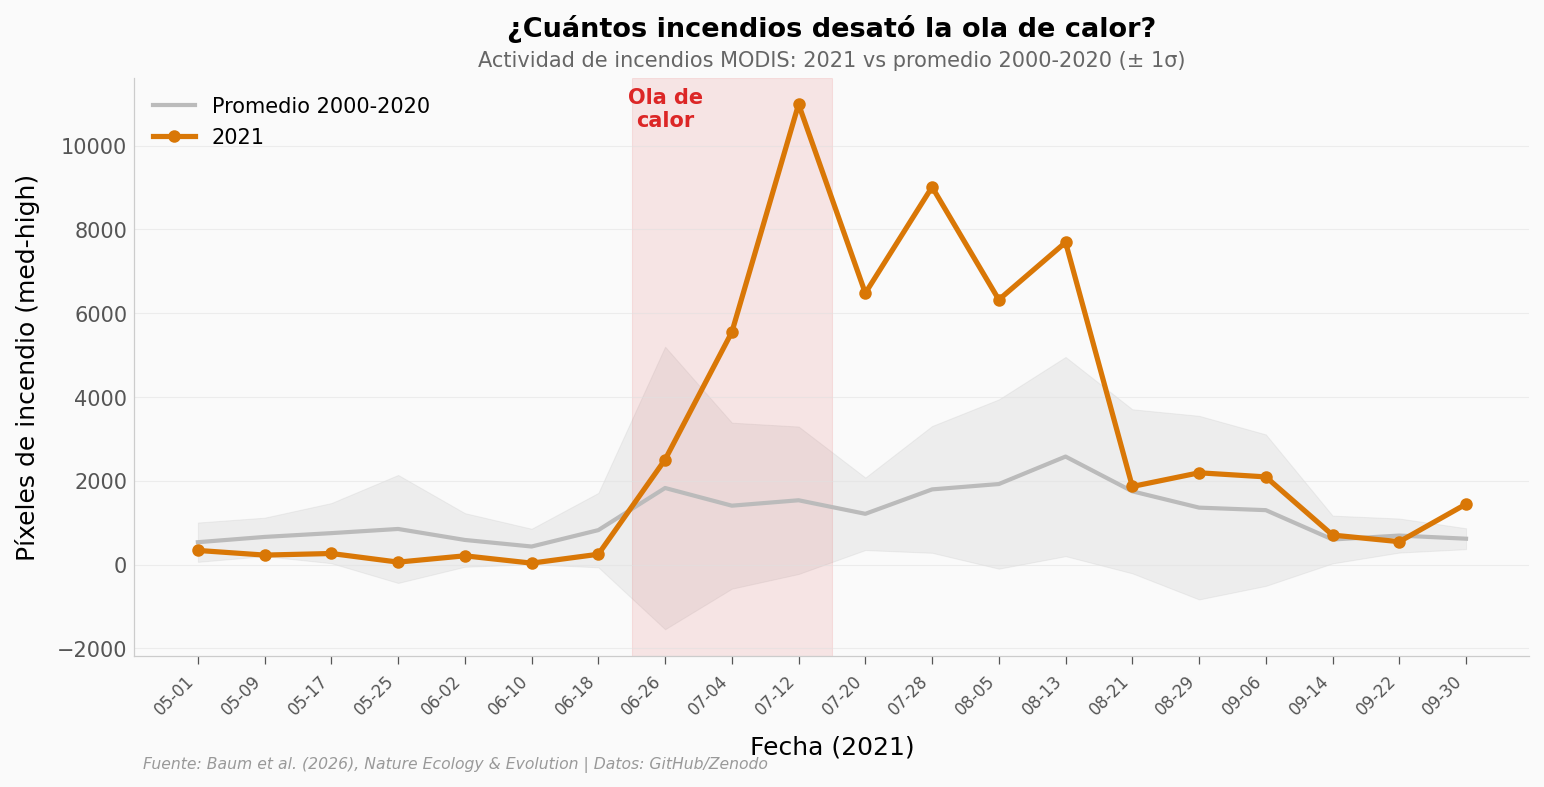

In [4]:
# Incendios forestales: 2021 vs promedio histórico (2000-2020)
fig, ax = plt.subplots(figsize=(12, 5))

# Historical average by date
wf_hist['md'] = pd.to_datetime(wf_hist.Date).dt.strftime('%m-%d')
wf21['md'] = pd.to_datetime(wf21.Date).dt.strftime('%m-%d')
hist_by_date = wf_hist.groupby('md').agg(
    mean=('fire_med_high', 'mean'),
    std=('fire_med_high', 'std')
).reset_index()

wf21_plot = wf21.merge(hist_by_date, on='md', how='left')
x = range(len(wf21_plot))

# Historical band
ax.fill_between(x, wf21_plot['mean'] - wf21_plot['std'],
                wf21_plot['mean'] + wf21_plot['std'],
                alpha=0.2, color=COLOR_HIST, label='_nolegend_')
ax.plot(x, wf21_plot['mean'], color=COLOR_HIST, linewidth=2, label='Promedio 2000-2020')

# 2021
ax.plot(x, wf21_plot.fire_med_high, color=COLOR_FIRE, linewidth=2.5,
        marker='o', markersize=5, label='2021')

# Heatwave annotation
hw_idx = [i for i, md in enumerate(wf21_plot.md) if '06-20' <= md <= '07-15']
if hw_idx:
    ax.axvspan(hw_idx[0] - 0.5, hw_idx[-1] + 0.5, alpha=0.1, color=COLOR_NEG, zorder=1)
    ax.text(hw_idx[0], ax.get_ylim()[1] * 0.9, 'Ola de\ncalor',
            fontsize=10, color=COLOR_NEG, fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels([d.split('-', 1)[1] for d in wf21_plot.Date],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Píxeles de incendio (med-high)', fontsize=12)
ax.set_xlabel('Fecha (2021)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_title('¿Cuántos incendios desató la ola de calor?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Actividad de incendios MODIS: 2021 vs promedio 2000-2020 (± 1σ)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/incendios_2021.png', dpi=200, bbox_inches='tight')
plt.show()

Después de la ola de calor, la actividad de incendios se disparó: en la semana siguiente, el área quemada fue ~3-7 veces mayor que el promedio histórico.

## ¿Qué tan fuera de lo normal fue el impacto?

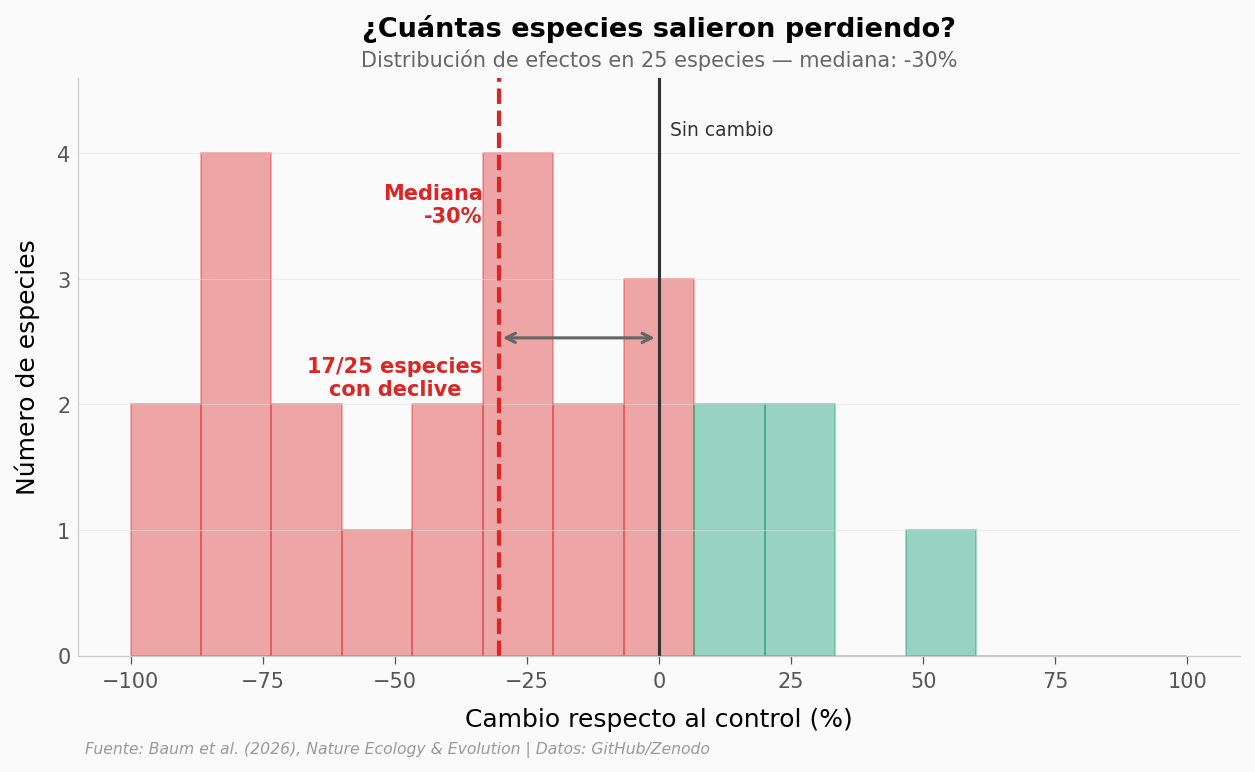

In [5]:
# Distribución de efectos: ¿qué tan lejos del cero están?
fig, ax = plt.subplots(figsize=(10, 5))

data = sp.mean_pct.values
n_vals, bins, patches = ax.hist(data, bins=15, color=COLOR_DATOS, alpha=0.4,
                                edgecolor=COLOR_DATOS, linewidth=0.8, range=(-100, 100))
# Color patches
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 0:
        patch.set_facecolor(COLOR_NEG)
        patch.set_edgecolor(COLOR_NEG)
    else:
        patch.set_facecolor(COLOR_POS)
        patch.set_edgecolor(COLOR_POS)
    patch.set_alpha(0.4)

y_max = n_vals.max() * 1.15
ax.set_ylim(0, y_max)

# Zero line
ax.axvline(x=0, color='#333333', linewidth=1.5, linestyle='-')
ax.text(2, y_max * 0.9, 'Sin cambio', fontsize=9, color='#333333')

# Median
med = np.median(data)
ax.axvline(x=med, color=COLOR_NEG, linewidth=2, linestyle='--')
ax.text(med - 3, y_max * 0.75, f'Mediana\n{med:.0f}%', fontsize=10,
        color=COLOR_NEG, fontweight='bold', ha='right')

# Arrow
ax.annotate('', xy=(med, y_max*0.55), xytext=(0, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

neg_n = (data < 0).sum()
ax.text(-50, y_max * 0.45, f'{neg_n}/{len(data)} especies\ncon declive',
        fontsize=10, color=COLOR_NEG, ha='center', fontweight='bold')

ax.set_xlabel('Cambio respecto al control (%)', fontsize=12)
ax.set_ylabel('Número de especies', fontsize=12)
ax.set_title('¿Cuántas especies salieron perdiendo?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución de efectos en {len(data)} especies — mediana: {med:.0f}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_efectos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Rango de efectos: -99% a +89% (entradas individuales) | ✅ | effectsizes.csv: -98,9% (*Ericaphis*) a +89,1% (*Regulus calendula*). Coincide con el paper. A nivel de especie (media): -99% a +51% |
| >75% de las especies impactadas negativamente | ⚠️ | Nuestro cálculo: 17/25 especies = 68% con media negativa; 25/41 mediciones = 61%. El paper reporta >75% — posiblemente incluye taxa adicionales (GPP, caudal) o un subconjunto diferente del dataset completo |
| Organismos sésiles más afectados que móviles | ✅ | Sésiles: media -58%, Móviles: media -24%. Mann-Whitney p = 0,04, Cohen's d = -0,86 (n=6 vs n=19 — muestra pequeña para sésiles) |
| Incendios se dispararon tras la ola de calor | ✅ | Datos MODIS: actividad ~3-7x mayor que el promedio 2000-2020 en la semana posterior al pico |
| Mediana del efecto ≈ -30% | ✅ | Mediana de las 25 medias por especie = -30,4% |

> **Limitaciones:** El dataset publicado contiene 25 de las 32 taxa mencionadas en el paper (posiblemente 7 taxa adicionales no están en effectsizes.csv). Los tamaños de muestra varían: sésiles marinos n=7 vs móviles n=18 — la comparación es indicativa pero no robusta con este n. Los datos de incendios (MODIS) miden píxeles de actividad, no área quemada directamente.

---

## Ahora tú

1. **¿Qué especie tuvo el mayor aumento proporcional?** Pista: `sp.sort_values('mean_pct', ascending=False).head(5)` — ¿son todas aves?

2. **¿Qué pasa si defines "impacto negativo" como un declive mayor al 10%?** Cambia `UMBRAL_NEGATIVO = -10` y observa cuántas especies quedan.

3. **¿Fue 2021 el peor año para incendios en todo el periodo?** Compara con `wf_hist.groupby('year').fire_med_high.sum().sort_values(ascending=False)` — ¿dónde cae 2021?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Top 5 especies con mayor aumento
print("Top 5 aumentos:")
print(sp.sort_values('mean_pct', ascending=False).head(5)[['genus_species', 'mean_pct', 'region', 'movement']].to_string())

# Total anual de incendios
print("\nActividad total de incendios por año:")
annual = wf_hist.groupby('year').fire_med_high.sum().sort_values(ascending=False)
total_2021 = wf21.fire_med_high.sum()
print(f"  2021: {total_2021:,.0f}".replace(',', '.'))
for yr, val in annual.head(5).items():
    marker = ' ← peor histórico' if yr == annual.index[0] else ''
    print(f"  {yr}: {val:,.0f}{marker}".replace(',', '.'))

Top 5 aumentos:
            genus_species   mean_pct       region movement
20      Regulus calendula  51.388630  terrestrial   motile
24                    bat  24.247312  terrestrial   motile
23  Troglodytes pacificus  21.595793  terrestrial   motile
3          Apis mellifera  14.880767  terrestrial   motile
8        Contopus cooperi  11.403732  terrestrial   motile

Actividad total de incendios por año:
  2021: 58.751
  2015: 53.126 ← peor histórico
  2017: 49.807
  2018: 38.069
  2012: 33.547
  2014: 30.652


---

**Paper:** Baum et al. (2026) *Widespread ecological responses and cascading effects of the 2021 western North American heatwave*, Nature Ecology & Evolution
**DOI:** [10.1038/s41559-026-02987-6](https://doi.org/10.1038/s41559-026-02987-6)
**Datos:** [GitHub](https://github.com/baumlab/2021NAmericanHeatwave) / [Zenodo (10.5281/zenodo.17833420)](https://doi.org/10.5281/zenodo.17833420)
**Licencia datos:** CC-BY 4.0 (Zenodo)
**Repo:** [Ciencia a Mordiscos / Lab](https://github.com/Ciencia-a-Mordiscos/lab)